# ResNet-34 / ResNet-50 구현, 학습, Ablation Study

노트북 순서
1. ResNet-34 / ResNet-50 모델 구현 (BasicBlock, Bottleneck, plain/residual 토글)
2. 구현한 모델로 Image Classification 학습 (loss 감소 확인)
3. Plain vs Residual Ablation Study (validation accuracy 비교표 + 곡선)


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import pandas as pd
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)


device: cuda


## 1. ResNet-34 / ResNet-50 모델 구현

- `BasicBlock` : ResNet-34에서 사용 (3x3 conv 2개, expansion=1)
- `Bottleneck` : ResNet-50에서 사용 (1x1 -> 3x3 -> 1x1, expansion=4)
- 두 블록 모두 `use_residual` 플래그로 **plain 버전 / residual 버전**을 동일한 코드에서 만들 수 있게 설계했습니다.
  (Ablation Study를 위해 residual 유무만 다르고 나머지는 완전히 동일한 모델이 필요하기 때문)


In [2]:
class BasicBlock(nn.Module):
    """ResNet-34에서 사용하는 기본 블록 (3x3 conv -> 3x3 conv)"""
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, downsample=None, use_residual=True):
        super().__init__()
        self.use_residual = use_residual

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                                stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                                stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = downsample  # 입력/출력 shape이 다를 때 shortcut 차원을 맞춰주는 1x1 conv

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.use_residual:
            if self.downsample is not None:
                identity = self.downsample(x)
            out = out + identity  # y = F(x) + x

        out = self.relu(out)
        return out


class Bottleneck(nn.Module):
    """ResNet-50/101/152에서 사용하는 Bottleneck 블록 (1x1 -> 3x3 -> 1x1, 채널 4배 확장)"""
    expansion = 4

    def __init__(self, in_channels, out_channels, stride=1, downsample=None, use_residual=True):
        super().__init__()
        self.use_residual = use_residual

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                                stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.conv3 = nn.Conv2d(out_channels, out_channels * self.expansion,
                                kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)

        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.use_residual:
            if self.downsample is not None:
                identity = self.downsample(x)
            out = out + identity

        out = self.relu(out)
        return out


In [ ]:
class ResNet(nn.Module):
    """BasicBlock 또는 Bottleneck을 받아 ResNet-34/50 구조를 만드는 범용 클래스"""

    def __init__(self, block, layers, num_classes=10, use_residual=True):
        super().__init__()
        self.in_channels = 64
        self.use_residual = use_residual

        # Stem: 7x7 conv stride2 + maxpool (ImageNet 스타일, 입력 224x224 기준)
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )

        # 4개의 stage. layers = [3,4,6,3] 이 ResNet-34/50 공통 반복 횟수
        self.layer1 = self._make_layer(block, 64, layers[0], stride=1)
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        downsample = None
        # stride!=1 이거나 채널 수가 달라지면(stage 진입 시) shortcut도 1x1 conv로 projection 필요
        if stride != 1 or self.in_channels != out_channels * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels * block.expansion,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * block.expansion),
            )

        layers = []
        layers.append(block(self.in_channels, out_channels, stride, downsample,
                             use_residual=self.use_residual))
        self.in_channels = out_channels * block.expansion
        for _ in range(1, num_blocks):
            layers.append(block(self.in_channels, out_channels,
                                 use_residual=self.use_residual))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


In [4]:
# 모델 factory 함수: residual=True/False로 plain / residual 버전을 동일 코드에서 생성

def resnet34(num_classes=10, residual=True):
    return ResNet(BasicBlock, [3, 4, 6, 3], num_classes=num_classes, use_residual=residual)

def resnet50(num_classes=10, residual=True):
    return ResNet(Bottleneck, [3, 4, 6, 3], num_classes=num_classes, use_residual=residual)


### summary로 구현 검증

- 각 stage를 거치며 출력 크기가 224 -> 112(stem conv) -> 56(maxpool) -> 56 -> 28 -> 14 -> 7 로 줄어드는지
- 파라미터 수가 논문 값(ResNet-34 ≈ 21.8M, ResNet-50 ≈ 25.6M, ImageNet 1000클래스 기준)과 비슷한 자릿수인지 확인합니다.
  (여기서는 num_classes를 바꿔서 쓰므로 fc층 파라미터 수만큼 약간 달라질 수 있습니다)


In [5]:
try:
    from torchinfo import summary
except ImportError:
    import sys, subprocess
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'torchinfo', '--break-system-packages', '-q'])
    from torchinfo import summary

model34 = resnet34(num_classes=1000, residual=True)
print('=' * 30, 'ResNet-34', '=' * 30)
summary(model34, input_size=(1, 3, 224, 224), depth=2)

model50 = resnet50(num_classes=1000, residual=True)
print('=' * 30, 'ResNet-50', '=' * 30)
summary(model50, input_size=(1, 3, 224, 224), depth=2)


============================== ResNet-34 ==============================
============================== ResNet-50 ==============================


Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 1000]                 --
├─Sequential: 1-1                        [1, 64, 56, 56]           --
│    └─Conv2d: 2-1                       [1, 64, 112, 112]         9,408
│    └─BatchNorm2d: 2-2                  [1, 64, 112, 112]         128
│    └─ReLU: 2-3                         [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                    [1, 64, 56, 56]           --
├─Sequential: 1-2                        [1, 256, 56, 56]          --
│    └─Bottleneck: 2-5                   [1, 256, 56, 56]          75,008
│    └─Bottleneck: 2-6                   [1, 256, 56, 56]          70,400
│    └─Bottleneck: 2-7                   [1, 256, 56, 56]          70,400
├─Sequential: 1-3                        [1, 512, 28, 28]          --
│    └─Bottleneck: 2-8                   [1, 512, 28, 28]          379,392
│    └─Bottleneck: 2-9                   [1, 512, 28, 28]       

## 2. 구현한 ResNet으로 Image Classification 학습

`torchvision.datasets`(CIFAR-10)을 이용해 loss가 실제로 감소하는지 확인합니다.
ResNet stem이 224x224 입력(ImageNet 스타일) 기준으로 설계되어 있으므로, transform에서 CIFAR-10(32x32) 이미지를 224x224로 resize합니다.

> 실제 과제 제출 시에는 epoch 수를 늘리고, 필요하면 CIFAR 전용 stem(3x3 conv, maxpool 제거)으로 바꿔서 학습 속도를 높이는 것도 고려해보세요.


In [6]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                          std=[0.2470, 0.2435, 0.2616]),
])

train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
val_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

BATCH_SIZE = 64
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print('train:', len(train_set), 'val:', len(val_set))


100%|██████████| 170M/170M [49:30<00:00, 57.4kB/s] 


train: 50000 val: 10000


In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    return running_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()

    val_loss = running_loss / len(loader.dataset)
    val_acc = correct / len(loader.dataset)
    return val_loss, val_acc


[epoch 1/3] train_loss=1.6071 val_loss=1.2440 val_acc=0.5608 (280.1s)
[epoch 2/3] train_loss=0.9915 val_loss=0.8615 val_acc=0.6941 (279.8s)
[epoch 3/3] train_loss=0.7239 val_loss=0.7514 val_acc=0.7401 (278.4s)


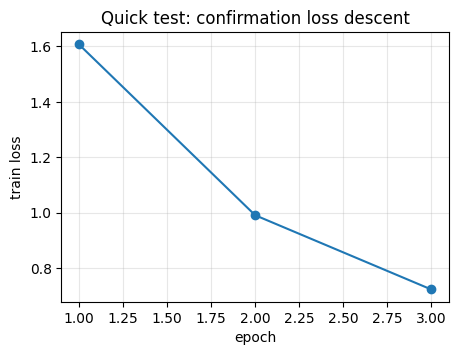

In [8]:
# 학습 파이프라인이 정상 동작하는지 (loss가 감소하는지) 확인하는 짧은 시험 학습
EPOCHS_QUICKTEST = 3

quick_model = resnet34(num_classes=10, residual=True).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(quick_model.parameters(), lr=1e-3)

train_losses = []
for epoch in range(EPOCHS_QUICKTEST):
    t0 = time.time()
    train_loss = train_one_epoch(quick_model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(quick_model, val_loader, criterion, device)
    train_losses.append(train_loss)
    print(f'[epoch {epoch+1}/{EPOCHS_QUICKTEST}] '
          f'train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_acc={val_acc:.4f} '
          f'({time.time()-t0:.1f}s)')

plt.figure(figsize=(5, 3.5))
plt.plot(range(1, EPOCHS_QUICKTEST + 1), train_losses, marker='o')
plt.xlabel('epoch')
plt.ylabel('train loss')
plt.title('Quick test: confirmation loss descent')
plt.grid(alpha=0.3)
plt.show()


## 3. Ablation Study — Plain vs Residual (ResNet-34, ResNet-50)

동일한 epoch 수, 동일한 optimizer/lr/batch size로 아래 4개 모델을 학습시키고 **validation accuracy**를 비교합니다.

1. ResNet-34 (plain)
2. ResNet-34 (residual)
3. ResNet-50 (plain)
4. ResNet-50 (residual)

기대되는 패턴: **plain은 깊어질수록(34->50) degradation으로 성능이 정체/악화될 수 있지만, residual은 깊어질수록(34->50) 성능이 향상**되어야 합니다.


In [9]:
def train_model(model_fn, residual, epochs, lr=1e-3):
    """model_fn: resnet34 또는 resnet50 factory 함수. 지정한 epoch만큼 학습 후 history 반환"""
    model = model_fn(num_classes=10, residual=residual).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    for epoch in range(epochs):
        t0 = time.time()
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f'  epoch {epoch+1}/{epochs} '
              f'train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_acc={val_acc:.4f} '
              f'({time.time()-t0:.1f}s)')

    return history


In [10]:
# 실습/빠른 검증용 기본값입니다. 실제 제출 시 EPOCHS를 늘려 충분히 학습시키세요 (예: 20~30 epoch).
EPOCHS = 10

configs = [
    ('ResNet-34', 'Plain',    resnet34, False),
    ('ResNet-34', 'Residual', resnet34, True),
    ('ResNet-50', 'Plain',    resnet50, False),
    ('ResNet-50', 'Residual', resnet50, True),
]

results = {}
for arch_name, variant_name, model_fn, use_residual in configs:
    print(f'\n===== {arch_name} - {variant_name} =====')
    history = train_model(model_fn, use_residual, epochs=EPOCHS)
    results[f'{arch_name}_{variant_name}'] = history



===== ResNet-34 - Plain =====
  epoch 1/10 train_loss=1.9135 val_loss=1.8470 val_acc=0.3122 (264.1s)
  epoch 2/10 train_loss=1.6277 val_loss=1.7202 val_acc=0.3828 (265.1s)
  epoch 3/10 train_loss=1.4941 val_loss=1.4338 val_acc=0.4775 (265.8s)
  epoch 4/10 train_loss=1.3325 val_loss=1.4558 val_acc=0.4788 (266.1s)
  epoch 5/10 train_loss=1.1684 val_loss=1.2299 val_acc=0.5424 (266.4s)
  epoch 6/10 train_loss=1.0410 val_loss=1.0668 val_acc=0.6138 (266.9s)
  epoch 7/10 train_loss=0.9316 val_loss=0.8990 val_acc=0.6838 (266.2s)
  epoch 8/10 train_loss=0.8473 val_loss=0.9269 val_acc=0.6792 (266.6s)
  epoch 9/10 train_loss=0.7740 val_loss=0.8635 val_acc=0.7059 (267.3s)
  epoch 10/10 train_loss=0.7079 val_loss=0.8572 val_acc=0.7040 (268.6s)

===== ResNet-34 - Residual =====
  epoch 1/10 train_loss=1.5597 val_loss=1.1753 val_acc=0.5740 (281.6s)
  epoch 2/10 train_loss=1.0049 val_loss=0.8638 val_acc=0.6986 (280.8s)
  epoch 3/10 train_loss=0.7368 val_loss=0.7220 val_acc=0.7460 (281.0s)
  epoch 4/1

In [11]:
# 결과표 작성
rows = []
for arch_name, variant_name, model_fn, use_residual in configs:
    key = f'{arch_name}_{variant_name}'
    final_val_acc = results[key]['val_acc'][-1]
    rows.append({
        'Model': arch_name,
        'Depth': 34 if arch_name == 'ResNet-34' else 50,
        'Residual 여부': variant_name,
        'Final Val Accuracy': round(final_val_acc, 4),
    })

ablation_df = pd.DataFrame(rows)
ablation_df


,Model,Depth,Residual 여부,Final Val Accuracy
0,ResNet-34,34,Plain,0.7040
1,ResNet-34,34,Residual,0.8457
2,ResNet-50,50,Plain,0.5945
3,ResNet-50,50,Residual,0.8217


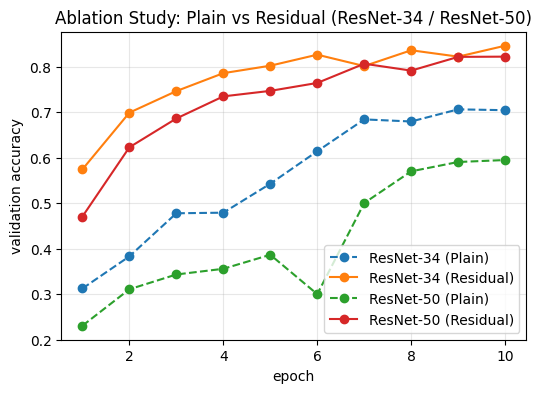

저장 완료: ablation_study_results.csv


In [12]:
# validation accuracy 곡선 비교 (degradation 재현 여부 시각적으로 확인)
plt.figure(figsize=(6, 4))
for arch_name, variant_name, model_fn, use_residual in configs:
    key = f'{arch_name}_{variant_name}'
    style = '-' if variant_name == 'Residual' else '--'
    plt.plot(range(1, EPOCHS + 1), results[key]['val_acc'], style,
              marker='o', label=f'{arch_name} ({variant_name})')

plt.xlabel('epoch')
plt.ylabel('validation accuracy')
plt.title('Ablation Study: Plain vs Residual (ResNet-34 / ResNet-50)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

ablation_df.to_csv('ablation_study_results.csv', index=False)
print('저장 완료: ablation_study_results.csv')
